# Interscorer analysis of timestamp agreement.
Previous planarian reports have rarely talked about scorers agreement among events in any detail. We want to give a fine picture of how our three scorerers have assessed 203 sample videos on a video-by-video basis. This notebook therefore quantifies inter-rater agreement across the three scorers by matching individual timestamps between scorers to determine which specific events were commonly identified and which were absent or misclassified (e.g. a turn as a contraction).

* **Cell 1** loads scorers; CSV, parses timestamp strings into lists, and merges all three into a single dataframe with one row per video. Only videos present in all three scorers' data are retained. 

* **Cell 2B I** defines the permutation infrastructure used by the unanimity analysis. For a given video, we generate every possible triplet (one timestamp from each scorer) and every possible 
pair (one timestamp from two scorers), recording pairwise frame differences and whether each pair falls within the matching threshold. Contractions and turns have different thresholds, with turns more stringent. The output is a sorted dataframe with triplets first, ordered by how tightly clustered the timestamps are (least difference between them).

* **Cell 2B II** is the matching pipeline that performs pairwise same-type matching (turns-to-turns, contractions-to-contractions) across all scorer pairs using a greedy closest-match algorithm that prevents any timestamp from being matched more than once. Timestamps that go unmatched in every pairwise comparison are designated orphans. Orphaned turns from one scorer are then compared against orphaned contractions from other scorers to detect potential turn/contraction type confusion (and vice versa). This is run across all videos and stored in `batch_results_all`, 
which is fed into subsequent cells.

* **Cell 3B** computes F1 inter-rater reliability metrics. Rather than re-running matching, it reshapes `batch_results_all` into a flat per-video counts dataframe and computes both macro-F1 (tp/fp/fn pooled across all videos before computing F1) and micro-F1 (F1 computed per video then averaged) for every scorer pair and event type.

* **Cell 4** generates a report from `batch_results_all`. For each ordered scorer pair it calculates how many of the reference scorer's events were matched, missed outright, or misclassified as the other event type, then aggregates these across all videos into a summary dataframe and a human-readable text report.

* **Cell 5** visualizes the macro-F1 results from Cell 3B as side-by-side heatmaps for turns and contractions, with reference scorer on the x-axis and test scorer on the y-axis.

* **Cell 6** computes 3-way unanimity. Using the triplet/pair permutations from Cell 2B I, a greedy assignment algorithm categorizes each unique event into a Venn diagram region: agreed upon by all three scorers (1∩2∩3), any two-scorer combination (2∩3, 1∩3, 1∩2), or marked by only one scorer. The inclusion-exclusion principle is then applied to count total unique events, and the 
unanimity rate is reported as 1∩2∩3 divided by that total.

## 1. Import the data and create scorer dictionaries.

In [15]:
import pdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from scipy.cluster.hierarchy import fclusterdata
import numpy as np
import seaborn as sns
from itertools import product

# CONFIGURATION: Update scorer dictionary of dictionaries with additional scorers.
SCORERS = {
    'Scorer_1': {
        'CSV': '/Users/zacharykelso/Desktop/Planarian_paper/Blind_Planarian_Scoring_Scorer_1.csv',
        'Enabled': True
    },
    'Scorer_2': {
        'CSV': '/Users/zacharykelso/Desktop/Planarian_paper/Blind_Planarian_Scoring_Scorer_2.csv',
        'Enabled': True
    },
    'Scorer_3': {
        'CSV': '/Users/zacharykelso/Desktop/Planarian_paper/Blind_Planarian_Scoring_Scorer_3.csv',
        'Enabled': True
    }
}
# ============================================================================
# HELPER FUNCTIONS - used to create compiled dataframe of scorer data.
# ============================================================================

def parse_timestamps(ts_string):
    """
    Convert timestamp string to list of integers.
    Handles empty/NaN values and header contamination.
    """
    if pd.isna(ts_string) or ts_string == '' or \
       ts_string == 'Turn_timestamps' or ts_string == 'Contraction_timestamps':
        return []
    
    try:
        return [int(x.strip()) for x in str(ts_string).split(',')]
    except ValueError as e:
        print(f"Warning: Error parsing timestamps '{ts_string}': {e}")
        return []


def load_scorer_data(csv_path, scorer_name):
    """
    Load and clean a single scorer's CSV file.
    
    Returns:
    --------
    DataFrame with columns:
        - video_key: standardized video identifier
        - turn_timestamps: list of integers
        - contraction_timestamps: list of integers
        - n_turns: count of turns
        - n_contractions: count of contractions
    """
    print(f"Loading {scorer_name}'s data from {csv_path}")
    
    df = pd.read_csv(csv_path, header=0)
    
    # Remove header contamination (if header appears as first data row)
    if 'Video_filename' in df.columns and df['Video_filename'].iloc[0] == 'Video_filename':
        df = df.iloc[1:].reset_index(drop=True)
        print(f"  → Removed duplicate header row")
    
    # Create standardized video key
    df['video_key'] = df['Video_filename'].str.replace('Video_', '').str.rstrip('/')
    
    # Parse timestamps into lists
    df['turn_timestamps'] = df['Turn_timestamps'].apply(parse_timestamps)
    df['contraction_timestamps'] = df['Contraction_timestamps'].apply(parse_timestamps)
    
    # Convert counts to numeric
    df['n_turns'] = pd.to_numeric(df['Number_turns'], errors='coerce').fillna(0).astype(int)
    df['n_contractions'] = pd.to_numeric(df['Number_contractions'], errors='coerce').fillna(0).astype(int)
    
    # Keep only needed columns and rename with scorer prefix
    result = df[['video_key', 'turn_timestamps', 'contraction_timestamps', 
                 'n_turns', 'n_contractions']].copy()
    
    result = result.rename(columns={
        'turn_timestamps': f'{scorer_name}_turn_timestamps',
        'contraction_timestamps': f'{scorer_name}_contraction_timestamps',
        'n_turns': f'{scorer_name}_turns',
        'n_contractions': f'{scorer_name}_contractions'
    })
    
    print(f"\tLoaded {len(result)} videos")
    print(f"\tAvg turns: {result[f'{scorer_name}_turns'].mean():.3f}"
          f"\n\tAvg contractions: {result[f'{scorer_name}_contractions'].mean():.3f}")
    
    return result


# ============================================================================
# MAIN FUNCTION
# ============================================================================

def compile_scorer_data(scorers=SCORERS):
    """
    Compile all enabled scorers' data into a single DataFrame.
    
    Returns:
    --------
    DataFrame with columns:
        - Video: video identifier
        - {scorer}_turns: count of turns for each scorer
        - {scorer}_turn_timestamps: list of turn timestamps for each scorer
        - {scorer}_contractions: count of contractions for each scorer
        - {scorer}_contraction_timestamps: list of contraction timestamps for each scorer
    
    One row per video (only videos scored by ALL enabled scorers).
    """
    
    # Get list of enabled scorers
    active_scorers = [name for name, config in scorers.items() if config['Enabled']]
    
    if not active_scorers:
        raise ValueError("No scorers enabled! Set at least one scorer to Enabled=True in SCORERS")
    
    print(f"COMPILING DATA FOR SCORERS: {', '.join(active_scorers)}")
    
    # Load each enabled scorer's data
    scorer_dfs = {}
    for scorer in active_scorers:
        csv_path = scorers[scorer]['CSV']
        scorer_dfs[scorer] = load_scorer_data(csv_path, scorer)
        print()
    
    # Start with first scorer as base
    print(f"COMPILATION: Trying to merge data across scorers...")
    combined_df = scorer_dfs[active_scorers[0]]
    
    # Merge additional scorers (inner join = only videos all scorers have)
    for scorer in active_scorers[1:]:
        combined_df = pd.merge(combined_df, scorer_dfs[scorer], 
                              on='video_key', how='inner')
    
    # Rename video_key to Video for clarity
    combined_df = combined_df.rename(columns={'video_key': 'Video'})
    
    # Reorder columns: Video first, then alphabetically by scorer
    video_col = ['Video']
    scorer_cols = []
    for scorer in sorted(active_scorers):
        scorer_cols.extend([
            f'{scorer}_contractions',
            f'{scorer}_contraction_timestamps',
            f'{scorer}_turns',
            f'{scorer}_turn_timestamps'
        ])
    
    combined_df = combined_df[video_col + scorer_cols]

    # Initialize a dictionary that describes how many events each scorer listed.
    # Used for sanity checks downstream.
    SCORER_SUMS = {
        'Scorer_1_turns':         [],
        'Scorer_2_turns':         [],
        'Scorer_3_turns':         [],
        'Scorer_1_contractions':  [],
        'Scorer_2_contractions':  [],
        'Scorer_3_contractions':  []
    }
 
    # Print summary
    print(f"COMPILATION: Compiling was successful.")
    print(f"\tVideos in final dataset: {len(combined_df)}")
    print(f"\tScorers included: {len(active_scorers)}")
    print(f"\tColumns: {len(combined_df.columns)}; matches expected value: {len(combined_df.columns) == (1 + 4 * len(active_scorers))}")
    
    # Basic statistics
    print("\n\nSUMMARY STATISTICS:")
    
    for scorer in sorted(active_scorers):
        turns_col = f'{scorer}_turns'
        contractions_col = f'{scorer}_contractions'
        
        print(f"\t{scorer}:")
        print(f"\t\tTurns\t\t Sum: {combined_df[turns_col].sum()}, "
              f"Mean: {combined_df[turns_col].mean():.3f}, "
              f"Std: {combined_df[turns_col].std():.3f}, "
              f"Range: {combined_df[turns_col].min()}-{combined_df[turns_col].max()}")
        print(f"\t\tContractions\t Sum: {combined_df[contractions_col].sum()}, "
              f"Mean: {combined_df[contractions_col].mean():.3f}, "
              f"Std: {combined_df[contractions_col].std():.3f}, "
              f"Range: {combined_df[contractions_col].min()}-{combined_df[contractions_col].max()}")
        print()

        SCORER_SUMS[f"{scorer}_turns"] = int(combined_df[turns_col].sum())
        SCORER_SUMS[f"{scorer}_contractions"] = int(combined_df[contractions_col].sum())
    
    print("\n\nCOMPILED DATAFRAME PREVIEW:")
    
    return combined_df, SCORER_SUMS


# RUN COMPILATION

# Create the dataframe
df, SCORER_SUMS = compile_scorer_data()
display(df.head())

# Show a quick dictionary of each scorer's sums
SCORER_SUMS

COMPILING DATA FOR SCORERS: Scorer_1, Scorer_2, Scorer_3
Loading Scorer_1's data from /Users/zacharykelso/Desktop/Planarian_paper/Blind_Planarian_Scoring_Scorer_1.csv
	Loaded 216 videos
	Avg turns: 2.667
	Avg contractions: 0.690

Loading Scorer_2's data from /Users/zacharykelso/Desktop/Planarian_paper/Blind_Planarian_Scoring_Scorer_2.csv
	Loaded 216 videos
	Avg turns: 1.921
	Avg contractions: 0.926

Loading Scorer_3's data from /Users/zacharykelso/Desktop/Planarian_paper/Blind_Planarian_Scoring_Scorer_3.csv
	Loaded 203 videos
	Avg turns: 1.177
	Avg contractions: 0.833

COMPILATION: Trying to merge data across scorers...
COMPILATION: Compiling was successful.
	Videos in final dataset: 203
	Scorers included: 3
	Columns: 13; matches expected value: True


SUMMARY STATISTICS:
	Scorer_1:
		Turns		 Sum: 531, Mean: 2.616, Std: 2.258, Range: 0-11
		Contractions	 Sum: 139, Mean: 0.685, Std: 1.181, Range: 0-10

	Scorer_2:
		Turns		 Sum: 385, Mean: 1.897, Std: 1.739, Range: 0-8
		Contractions	 Su

,Video,Scorer_1_contractions,Scorer_1_contraction_timestamps,Scorer_1_turns,Scorer_1_turn_timestamps,Scorer_2_contractions,Scorer_2_contraction_timestamps,Scorer_2_turns,Scorer_2_turn_timestamps,Scorer_3_contractions,Scorer_3_contraction_timestamps,Scorer_3_turns,Scorer_3_turn_timestamps
0,Ahead_Tasty_Chicory,1,[62],2,"[62, 228]",0,[],1,[241],0,[],0,[]
1,Abhorrent_Jittery_Trap,0,[],5,"[86, 120, 131, 141, 199]",0,[],5,"[89, 110, 133, 195, 269]",0,[],2,"[116, 205]"
2,Aback_Gentle_Deduce,2,"[128, 141]",2,"[128, 141]",1,[141],1,[127],1,[134],1,[143]
3,Abounding_Wholesale_Van,0,[],4,"[47, 66, 80, 206]",0,[],4,"[48, 62, 84, 196]",0,[],2,"[52, 205]"
4,Absorbed_Muddled_Chaos,1,[143],2,"[90, 143]",1,[146],2,"[90, 120]",1,[146],0,[]


{'Scorer_1_turns': 531,
 'Scorer_2_turns': 385,
 'Scorer_3_turns': 239,
 'Scorer_1_contractions': 139,
 'Scorer_2_contractions': 191,
 'Scorer_3_contractions': 169}

## 2B I. Define and execute multidimensional approach functions.
Outputs a dataframe of all triplet and pairwise combinations of timestamps in a video.

In [16]:
# ============================================================================
# TIMESTAMP PERMUTATION ANALYSIS (TRIPLETS + PAIRS)
# ============================================================================

# CONFIGURATION: Thresholds for matching - these are updated later when functions actually called.
TURN_THRESHOLD = 10
CONTRACTION_THRESHOLD = 15

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def extract_timestamps_for_video(df, video_name, scorers=['Scorer_1', 'Scorer_2', 'Scorer_3']):
    """
    Extract timestamp data for a single video across all scorers.
    
    Parameters:
    -----------
    df : DataFrame
        The compiled dataframe from compile_scorer_data()
    video_name : str
        The video identifier
    scorers : list
        List of scorer names (order matters for columns)
    
    Returns:
    --------
    dict with keys 'turns' and 'contractions', each containing:
        {scorer_name: list of timestamps}
    """
    video_row = df[df['Video'] == video_name].iloc[0]
    
    result = {
        'turns': {},
        'contractions': {}
    }
    
    for scorer in scorers:
        result['turns'][scorer] = video_row[f'{scorer}_turn_timestamps']
        result['contractions'][scorer] = video_row[f'{scorer}_contraction_timestamps']
    
    return result


def create_triplet_and_pair_permutations(timestamps_dict, event_type, threshold, 
                                         scorers=['Scorer_1', 'Scorer_2', 'Scorer_3']):
    """
    Create all possible triplet AND pair combinations from scorer timestamps.
    
    Parameters:
    -----------
    timestamps_dict : dict
        Dictionary with scorer names as keys, lists of timestamps as values
    event_type : str
        'turn' or 'contraction'
    threshold : int
        Frame difference threshold for agreement
    scorers : list
        List of scorer names in order [corresponds to S1, S2, S3 in column names]
    
    Returns:
    --------
    DataFrame with all triplet and pair permutations, sorted by:
        - Triplets first (sorted by diff_range, then total_diff)
        - Then pairs (sorted by total_diff)
    """
    
    # Extract timestamp lists in order
    ts_lists = [timestamps_dict[scorer] for scorer in scorers]
    
    # Check if all scorers have no timestamps
    if all(len(ts) == 0 for ts in ts_lists):
        print(f"  Warning: All scorers have no {event_type} timestamps")
        return pd.DataFrame(columns=[
            'combination_type', 'Triplet', 'event_type', 'threshold',
            'S1_value', 'S2_value', 'S3_value',
            'S1_index', 'S2_index', 'S3_index',
            'S1S2_diff', 'S2S3_diff', 'S1S3_diff',
            'S1S2_pass', 'S2S3_pass', 'S1S3_pass',
            'total_diff', 'diff_range', 'agreement_count'
        ])
        
    combinations = []
    
    # ========================================================================
    # TRIPLETS: All three scorers
    # ========================================================================
    if all(len(ts) > 0 for ts in ts_lists):
        for s1_idx, s1_val in enumerate(ts_lists[0]):
            for s2_idx, s2_val in enumerate(ts_lists[1]):
                for s3_idx, s3_val in enumerate(ts_lists[2]):
                    
                    # Calculate pairwise differences
                    s1s2_diff = abs(s1_val - s2_val)
                    s2s3_diff = abs(s2_val - s3_val)
                    s1s3_diff = abs(s1_val - s3_val)
                    
                    # Check if differences pass threshold
                    s1s2_pass = s1s2_diff <= threshold
                    s2s3_pass = s2s3_diff <= threshold
                    s1s3_pass = s1s3_diff <= threshold
                    
                    # Calculate aggregate metrics
                    total_diff = s1s2_diff + s2s3_diff + s1s3_diff
                    diff_range = max(s1s2_diff, s2s3_diff, s1s3_diff) - min(s1s2_diff, s2s3_diff, s1s3_diff)
                    
                    agreement_count = int(s1s2_pass) + int(s2s3_pass) + int(s1s3_pass)
                    
                    combinations.append({
                        'combination_type': 'triplet',
                        'Triplet': (s1_val, s2_val, s3_val),
                        'event_type': event_type,
                        'threshold': threshold,
                        'S1_value': s1_val,
                        'S2_value': s2_val,
                        'S3_value': s3_val,
                        'S1_index': s1_idx,
                        'S2_index': s2_idx,
                        'S3_index': s3_idx,
                        'S1S2_diff': s1s2_diff,
                        'S2S3_diff': s2s3_diff,
                        'S1S3_diff': s1s3_diff,
                        'S1S2_pass': s1s2_pass,
                        'S2S3_pass': s2s3_pass,
                        'S1S3_pass': s1s3_pass,
                        'total_diff': total_diff,
                        'diff_range': diff_range,
                        'agreement_count': agreement_count
                    })
    
    # ========================================================================
    # PAIRS: Two scorers at a time
    # ========================================================================
    
    # Pair 1: S1 and S2 (S3 is NaN)
    if len(ts_lists[0]) > 0 and len(ts_lists[1]) > 0:
        for s1_idx, s1_val in enumerate(ts_lists[0]):
            for s2_idx, s2_val in enumerate(ts_lists[1]):
                
                s1s2_diff = abs(s1_val - s2_val)
                s1s2_pass = s1s2_diff <= threshold
                
                combinations.append({
                    'combination_type': 'pair',
                    'Triplet': (s1_val, s2_val, np.nan),
                    'event_type': event_type,
                    'threshold': threshold,
                    'S1_value': s1_val,
                    'S2_value': s2_val,
                    'S3_value': np.nan,
                    'S1_index': s1_idx,
                    'S2_index': s2_idx,
                    'S3_index': np.nan,
                    'S1S2_diff': s1s2_diff,
                    'S2S3_diff': np.nan,
                    'S1S3_diff': np.nan,
                    'S1S2_pass': s1s2_pass,
                    'S2S3_pass': np.nan,
                    'S1S3_pass': np.nan,
                    'total_diff': s1s2_diff,
                    'diff_range': 0,
                    'agreement_count': int(s1s2_pass)
                })
    
    # Pair 2: S1 and S3 (S2 is NaN)
    if len(ts_lists[0]) > 0 and len(ts_lists[2]) > 0:
        for s1_idx, s1_val in enumerate(ts_lists[0]):
            for s3_idx, s3_val in enumerate(ts_lists[2]):
                
                s1s3_diff = abs(s1_val - s3_val)
                s1s3_pass = s1s3_diff <= threshold
                
                combinations.append({
                    'combination_type': 'pair',
                    'Triplet': (s1_val, np.nan, s3_val),
                    'event_type': event_type,
                    'threshold': threshold,
                    'S1_value': s1_val,
                    'S2_value': np.nan,
                    'S3_value': s3_val,
                    'S1_index': s1_idx,
                    'S2_index': np.nan,
                    'S3_index': s3_idx,
                    'S1S2_diff': np.nan,
                    'S2S3_diff': np.nan,
                    'S1S3_diff': s1s3_diff,
                    'S1S2_pass': np.nan,
                    'S2S3_pass': np.nan,
                    'S1S3_pass': s1s3_pass,
                    'total_diff': s1s3_diff,
                    'diff_range': 0,
                    'agreement_count': int(s1s3_pass)
                })
    
    # Pair 3: S2 and S3 (S1 is NaN)
    if len(ts_lists[1]) > 0 and len(ts_lists[2]) > 0:
        for s2_idx, s2_val in enumerate(ts_lists[1]):
            for s3_idx, s3_val in enumerate(ts_lists[2]):
                
                s2s3_diff = abs(s2_val - s3_val)
                s2s3_pass = s2s3_diff <= threshold
                
                combinations.append({
                    'combination_type': 'pair',
                    'Triplet': (np.nan, s2_val, s3_val),
                    'event_type': event_type,
                    'threshold': threshold,
                    'S1_value': np.nan,
                    'S2_value': s2_val,
                    'S3_value': s3_val,
                    'S1_index': np.nan,
                    'S2_index': s2_idx,
                    'S3_index': s3_idx,
                    'S1S2_diff': np.nan,
                    'S2S3_diff': s2s3_diff,
                    'S1S3_diff': np.nan,
                    'S1S2_pass': np.nan,
                    'S2S3_pass': s2s3_pass,
                    'S1S3_pass': np.nan,
                    'total_diff': s2s3_diff,
                    'diff_range': 0,
                    'agreement_count': int(s2s3_pass)
                })
    
    # Create DataFrame
    permutations_df = pd.DataFrame(combinations)
    
    if len(permutations_df) == 0:
        return permutations_df
    
    # ========================================================================
    # SORT: Triplets first (by diff_range, then total_diff), 
    #       then Pairs (by total_diff)
    # ========================================================================
    
    triplets = permutations_df[permutations_df['combination_type'] == 'triplet'].copy()
    pairs = permutations_df[permutations_df['combination_type'] == 'pair'].copy()
    
    if len(triplets) > 0:
        triplets = triplets.sort_values(
            by=['diff_range', 'total_diff'],
            ascending=[True, True]
        ).reset_index(drop=True)
    
    if len(pairs) > 0:
        pairs = pairs.sort_values(
            by=['total_diff'],
            ascending=[True]
        ).reset_index(drop=True)
    
    permutations_df = pd.concat([triplets, pairs], ignore_index=True)
    
    return permutations_df


# ============================================================================
# MAIN ANALYSIS FUNCTION
# ============================================================================

def analyze_video_timestamps(df, video_name, turn_threshold=TURN_THRESHOLD, 
                            contraction_threshold=CONTRACTION_THRESHOLD):
    """
    Create permutation dataframes (triplets + pairs) for a single video's turns and contractions.
    
    Parameters:
    -----------
    df : DataFrame
        Compiled scorer dataframe
    video_name : str
        Video identifier
    turn_threshold : int
        Frame threshold for turn matching
    contraction_threshold : int
        Frame threshold for contraction matching
    
    Returns:
    --------
    dict with keys 'turns' and 'contractions', each containing a permutations DataFrame
    """
    
    print(f"ANALYZING VIDEO: {video_name}")
    print("=" * 60)
    
    # Extract timestamps
    timestamps = extract_timestamps_for_video(df, video_name)
    
    # Print counts
    print("\nTimestamp counts:")
    for event_type in ['turns', 'contractions']:
        print(f"  {event_type.capitalize()}:")
        for scorer, ts_list in timestamps[event_type].items():
            print(f"    {scorer}: {len(ts_list)}")
    
    # Create permutation dataframes
    print("\nCreating permutations (triplets + pairs)...")
    
    turns_df = create_triplet_and_pair_permutations(
        timestamps['turns'], 
        'turn', 
        turn_threshold
    )
    
    if len(turns_df) > 0:
        n_triplets = (turns_df['combination_type'] == 'triplet').sum()
        n_pairs = (turns_df['combination_type'] == 'pair').sum()
        print(f"  Turns: {len(turns_df)} total combinations ({n_triplets} triplets, {n_pairs} pairs)")
    else:
        print(f"  Turns: 0 combinations")
    
    contractions_df = create_triplet_and_pair_permutations(
        timestamps['contractions'], 
        'contraction', 
        contraction_threshold
    )
    
    if len(contractions_df) > 0:
        n_triplets = (contractions_df['combination_type'] == 'triplet').sum()
        n_pairs = (contractions_df['combination_type'] == 'pair').sum()
        print(f"  Contractions: {len(contractions_df)} total combinations ({n_triplets} triplets, {n_pairs} pairs)")
    else:
        print(f"  Contractions: 0 combinations")
    
    # Print agreement distribution for triplets
    if len(turns_df) > 0:
        triplet_turns = turns_df[turns_df['combination_type'] == 'triplet']
        if len(triplet_turns) > 0:
            print(f"\n  Turn TRIPLET agreement distribution:")
            print(f"    3-way agreement: {(triplet_turns['agreement_count'] == 3).sum()}")
            print(f"    2-way agreement: {(triplet_turns['agreement_count'] == 2).sum()}")
            print(f"    1-way agreement: {(triplet_turns['agreement_count'] == 1).sum()}")
            print(f"    0-way agreement: {(triplet_turns['agreement_count'] == 0).sum()}")
        
        pair_turns = turns_df[turns_df['combination_type'] == 'pair']
        if len(pair_turns) > 0:
            print(f"\n  Turn PAIR agreement distribution:")
            print(f"    Agreement: {(pair_turns['agreement_count'] == 1).sum()}")
            print(f"    No agreement: {(pair_turns['agreement_count'] == 0).sum()}")
    
    if len(contractions_df) > 0:
        triplet_contractions = contractions_df[contractions_df['combination_type'] == 'triplet']
        if len(triplet_contractions) > 0:
            print(f"\n  Contraction TRIPLET agreement distribution:")
            print(f"    3-way agreement: {(triplet_contractions['agreement_count'] == 3).sum()}")
            print(f"    2-way agreement: {(triplet_contractions['agreement_count'] == 2).sum()}")
            print(f"    1-way agreement: {(triplet_contractions['agreement_count'] == 1).sum()}")
            print(f"    0-way agreement: {(triplet_contractions['agreement_count'] == 0).sum()}")
        
        pair_contractions = contractions_df[contractions_df['combination_type'] == 'pair']
        if len(pair_contractions) > 0:
            print(f"\n  Contraction PAIR agreement distribution:")
            print(f"    Agreement: {(pair_contractions['agreement_count'] == 1).sum()}")
            print(f"    No agreement: {(pair_contractions['agreement_count'] == 0).sum()}")
    
    return {
        'turns': turns_df,
        'contractions': contractions_df
    }


# ============================================================================
# RUN ANALYSIS ON VIDEO
# ============================================================================

test_video = df['Video'].iloc[25]

# timestamp_combinations_df = analyze_video_timestamps(df, test_video)

# print("\n" + "=" * 60)
# print("TURNS PERMUTATIONS DATAFRAME (Triplets + Pairs):")
# print("=" * 60)
# display(timestamp_combinations_df['turns'].head(30))

# print("\n" + "=" * 60)
# print("CONTRACTIONS PERMUTATIONS DATAFRAME (Triplets + Pairs):")
# print("=" * 60)
# display(timestamp_combinations_df['contractions'].head(30))

## 2B II. Process timestamps dataframe to match like and cross-type events.
Uses 2B I's outputted dataframe of timestamp combinations to select for turn-turn and con-con matches, then looks at turn/con confusion of the orphans.

In [17]:
# ============================================================================
# CELL 2B II: COMPREHENSIVE MATCHING & CROSS-TYPE ANALYSIS
# ============================================================================
# Purpose: 
# 1. Perform pairwise same-type matching with index tracking
# 2. Identify orphaned timestamps
# 3. Generate cross-type permutations between orphans
# ============================================================================

# CONFIGURATION
CROSS_TYPE_THRESHOLD = 10  # Threshold for considering turn-contraction confusion


# ============================================================================
# CORE MATCHING FUNCTION
# ============================================================================

def match_timestamps_comprehensive(timestamps_ref, timestamps_test, threshold=15):
    """
    Enhanced version of match_timestamps_optimal that returns BOTH:
    - Match statistics (tp, fp, fn) for F1 calculation
    - Matched indices for orphan identification
    
    This is the single source of truth for matching - no duplication.
    
    Parameters:
    -----------
    timestamps_ref : list
        Reference scorer's timestamps
    timestamps_test : list
        Test scorer's timestamps
    threshold : int
        Frame difference threshold for matching
    
    Returns:
    --------
    dict with:
        'tp': int - true positives
        'fp': int - false positives  
        'fn': int - false negatives
        'both_empty': bool
        'matched_ref_indices': set - which ref indices got matched
        'matched_test_indices': set - which test indices got matched
        'matches': list of dicts - each match with {ref_idx, test_idx, ref_time, test_time, diff}
    """
    
    # Handle edge cases
    if len(timestamps_test) == 0 and len(timestamps_ref) == 0:
        return {
            'tp': 0, 'fp': 0, 'fn': 0, 'both_empty': True,
            'matched_ref_indices': set(),
            'matched_test_indices': set(),
            'matches': []
        }
    
    if len(timestamps_test) == 0:
        return {
            'tp': 0, 'fp': 0, 'fn': len(timestamps_ref), 'both_empty': False,
            'matched_ref_indices': set(),
            'matched_test_indices': set(),
            'matches': []
        }
    
    if len(timestamps_ref) == 0:
        return {
            'tp': 0, 'fp': len(timestamps_test), 'fn': 0, 'both_empty': False,
            'matched_ref_indices': set(),
            'matched_test_indices': set(),
            'matches': []
        }
    
    # ========================================================================
    # STEP 1: Generate all possible pairs within threshold
    # ========================================================================
    possible_matches = []
    
    for test_idx, test_time in enumerate(timestamps_test):
        for ref_idx, ref_time in enumerate(timestamps_ref):
            diff = abs(test_time - ref_time)
            if diff <= threshold:
                possible_matches.append({
                    'test_idx': test_idx,
                    'ref_idx': ref_idx,
                    'test_time': test_time,
                    'ref_time': ref_time,
                    'diff': diff
                })
    
    # ========================================================================
    # STEP 2: Sort by difference (prefer closest matches)
    # ========================================================================
    possible_matches.sort(key=lambda x: x['diff'])
    
    # ========================================================================
    # STEP 3: Greedy assignment (no reuse)
    # ========================================================================
    matched_ref = set()
    matched_test = set()
    final_matches = []
    
    for match in possible_matches:
        test_idx = match['test_idx']
        ref_idx = match['ref_idx']
        
        # Only assign if neither timestamp has been used
        if test_idx not in matched_test and ref_idx not in matched_ref:
            matched_test.add(test_idx)
            matched_ref.add(ref_idx)
            final_matches.append(match)
    
    # ========================================================================
    # STEP 4: Calculate TP, FP, FN
    # ========================================================================
    tp = len(matched_test)  # Successfully matched pairs
    fp = len(timestamps_test) - len(matched_test)  # Unmatched test timestamps
    fn = len(timestamps_ref) - len(matched_ref)    # Unmatched ref timestamps
    
    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'both_empty': False,
        'matched_ref_indices': matched_ref,
        'matched_test_indices': matched_test,
        'matches': final_matches
    }


# ============================================================================
# VIDEO-LEVEL SAME-TYPE MATCHING
# ============================================================================

def perform_video_matching(df, video_name, turn_threshold=10, contraction_threshold=15,
                          scorers=['Scorer_1', 'Scorer_2', 'Scorer_3'], verbose=True):
    """
    Perform comprehensive same-type matching for a single video across all scorer pairs.
    
    verbose : bool
        If True, print detailed progress. If False, silent operation.
    """
    
    if verbose:
        print(f"PERFORMING SAME-TYPE MATCHING FOR VIDEO: {video_name}")
        print("=" * 60)
    
    # Extract timestamps for this video
    video_row = df[df['Video'] == video_name].iloc[0]
    
    results = {
        'video': video_name,
        'turns': {},
        'contractions': {}
    }
    
    # For each event type
    for event_type, threshold in [('turn', turn_threshold), ('contraction', contraction_threshold)]:
        
        if verbose:
            print(f"\n{event_type.upper()}S:")
        
        # Get all scorer timestamps for this event type
        scorer_timestamps = {}
        for scorer in scorers:
            col_name = f'{scorer}_{event_type}_timestamps'
            scorer_timestamps[scorer] = video_row[col_name]
        
        # Perform pairwise matching
        for i, scorer_ref in enumerate(scorers):
            for scorer_test in scorers[i+1:]:  # Only upper triangle, avoid duplicates
                
                match_results = match_timestamps_comprehensive(
                    scorer_timestamps[scorer_ref],
                    scorer_timestamps[scorer_test],
                    threshold
                )
                
                # Store with clear ref/test roles
                event_dict = results['turns'] if event_type == 'turn' else results['contractions']
                event_dict[(scorer_ref, scorer_test)] = match_results
                
                if verbose:
                    print(f"  {scorer_ref} vs {scorer_test}: {match_results['tp']} matches, "
                          f"{match_results['fp']} FP ({scorer_test} orphans), "
                          f"{match_results['fn']} FN ({scorer_ref} orphans)")
    
    return results


# ============================================================================
# ORPHAN IDENTIFICATION
# ============================================================================

def identify_orphans_from_matching(df, video_name, matching_results,
                                   scorers=['Scorer_1', 'Scorer_2', 'Scorer_3'], verbose=True):
    """
    Identify orphaned timestamps from comprehensive matching results.
    
    verbose : bool
        If True, print detailed progress. If False, silent operation.
    """
    
    if verbose:
        print(f"\nIDENTIFYING ORPHANS FOR VIDEO: {video_name}")
        print("=" * 60)
    
    # Get original timestamps
    video_row = df[df['Video'] == video_name].iloc[0]
    
    orphans = {
        'turns': {},
        'contractions': {}
    }
    
    for event_type in ['turn', 'contraction']:
        
        if verbose:
            print(f"\n{event_type.upper()}S:")
        event_key = 'turns' if event_type == 'turn' else 'contractions'
        
        for scorer in scorers:
            
            # Get full timestamp list for this scorer
            col_name = f'{scorer}_{event_type}_timestamps'
            all_timestamps = video_row[col_name]
            
            if len(all_timestamps) == 0:
                orphans[event_key][scorer] = []
                if verbose:
                    print(f"  {scorer}: 0 total, 0 orphans")
                continue
            
            # Collect ALL indices that were matched in ANY pairwise comparison
            matched_indices = set()
            
            for other_scorer in scorers:
                if other_scorer == scorer:
                    continue
                
                # Check both possible pair orderings
                pair_key_1 = (scorer, other_scorer)
                pair_key_2 = (other_scorer, scorer)
                
                # If scorer is "ref" in stored pair
                if pair_key_1 in matching_results[event_key]:
                    match_data = matching_results[event_key][pair_key_1]
                    matched_indices.update(match_data.get('matched_ref_indices', set()))
                
                # If scorer is "test" in stored pair
                if pair_key_2 in matching_results[event_key]:
                    match_data = matching_results[event_key][pair_key_2]
                    matched_indices.update(match_data.get('matched_test_indices', set()))
            
            # Find orphan indices = all indices NOT in matched_indices
            orphan_indices = set(range(len(all_timestamps))) - matched_indices
            
            # Extract orphan timestamp values
            orphan_timestamps = [all_timestamps[idx] for idx in sorted(orphan_indices)]
            orphans[event_key][scorer] = orphan_timestamps
            
            if verbose:
                print(f"  {scorer}: {len(all_timestamps)} total, {len(orphan_timestamps)} orphans")
    
    return orphans


# ============================================================================
# CROSS-TYPE PERMUTATION GENERATION
# ============================================================================

def create_cross_type_permutations(orphans, cross_type_threshold=20, 
                                   scorers=['Scorer_1', 'Scorer_2', 'Scorer_3'], verbose=True):
    """
    Create all possible cross-type pairings between orphaned turns and contractions.
    
    verbose : bool
        If True, print detailed progress. If False, silent operation.
    """
    
    if verbose:
        print(f"\nCREATING CROSS-TYPE PERMUTATIONS")
        print("=" * 60)
        print(f"Threshold: {cross_type_threshold} frames")
    
    cross_type_combinations = []
    
    # For each scorer's orphan turns
    for turn_scorer in scorers:
        for turn_value in orphans['turns'][turn_scorer]:
            
            # Match against OTHER scorers' orphan contractions
            for contraction_scorer in scorers:
                
                # Skip same scorer (within-scorer doesn't make sense)
                if turn_scorer == contraction_scorer:
                    continue
                
                for contraction_value in orphans['contractions'][contraction_scorer]:
                    
                    diff = abs(turn_value - contraction_value)
                    passes = (diff <= cross_type_threshold)
                    
                    cross_type_combinations.append({
                        'Turn_scorer': turn_scorer,
                        'Turn_value': turn_value,
                        'Contraction_scorer': contraction_scorer,
                        'Contraction_value': contraction_value,
                        'abs_difference': diff,
                        'within_threshold': passes
                    })
    
    # Create DataFrame with proper column structure even if empty
    if len(cross_type_combinations) == 0:
        cross_type_df = pd.DataFrame(columns=[
            'Turn_scorer', 'Turn_value', 'Contraction_scorer', 
            'Contraction_value', 'abs_difference', 'within_threshold'
        ])
    else:
        cross_type_df = pd.DataFrame(cross_type_combinations)
        cross_type_df = cross_type_df.sort_values('abs_difference').reset_index(drop=True)
    
    if verbose:
        print(f"\nTotal cross-type combinations: {len(cross_type_df)}")
        if len(cross_type_df) > 0:
            n_within = cross_type_df['within_threshold'].sum()
            print(f"  Within threshold: {n_within}")
            print(f"  Outside threshold: {len(cross_type_df) - n_within}")
            
            if n_within > 0:
                closest = cross_type_df[cross_type_df['within_threshold']]['abs_difference'].min()
                furthest = cross_type_df[cross_type_df['within_threshold']]['abs_difference'].max()
                print(f"  Closest match within threshold: {closest} frames")
                print(f"  Furthest match within threshold: {furthest} frames")
        else:
            print(f"  No orphan cross-type combinations found (good inter-rater agreement!)")
    
    return cross_type_df


# ============================================================================
# MASTER ANALYSIS FUNCTION
# ============================================================================

def analyze_video_cross_type(df, video_name, turn_threshold=10, contraction_threshold=15,
                             cross_type_threshold=20,
                             scorers=['Scorer_1', 'Scorer_2', 'Scorer_3'], verbose=True):
    """
    Master function: Perform complete same-type and cross-type analysis for one video.
    
    verbose : bool
        If True, print detailed progress. If False, silent operation.
    """
    
    if verbose:
        print("=" * 80)
        print(f"COMPLETE TIMESTAMP ANALYSIS: {video_name}")
        print("=" * 80)
    
    # Step 1: Same-type matching
    matching_results = perform_video_matching(
        df, video_name, turn_threshold, contraction_threshold, scorers, verbose=verbose
    )
    
    # Step 2: Identify orphans
    orphans = identify_orphans_from_matching(
        df, video_name, matching_results, scorers, verbose=verbose
    )
    
    # Step 3: Cross-type analysis
    cross_type_df = create_cross_type_permutations(
        orphans, cross_type_threshold, scorers, verbose=verbose
    )
    
    return {
        'matching_results': matching_results,
        'orphans': orphans,
        'cross_type_df': cross_type_df
    }


# ============================================================================
# EXECUTE ON TEST VIDEO
# ============================================================================

# test_video is defined in Cell 2B I
cross_type_results = analyze_video_cross_type(
    df,
    test_video,
    turn_threshold=TURN_THRESHOLD,
    contraction_threshold=CONTRACTION_THRESHOLD,
    cross_type_threshold=CROSS_TYPE_THRESHOLD
)

# Display cross-type results
print("\n" + "=" * 80)
print("CROSS-TYPE ORPHAN PERMUTATIONS (All Combinations):")
print("=" * 80)
display(cross_type_results['cross_type_df'].head(30))

# Show only those within threshold
print("\n" + "=" * 80)
print("CROSS-TYPE MATCHES WITHIN THRESHOLD:")
print("=" * 80)
within_threshold = cross_type_results['cross_type_df'][
    cross_type_results['cross_type_df']['within_threshold'] == True
]
display(within_threshold)

# Print summary statistics
if len(within_threshold) > 0:
    print("\n" + "=" * 80)
    print("SUMMARY OF POTENTIAL CROSS-TYPE CONFUSIONS:")
    print("=" * 80)
    
    print("\nBy scorer pair:")
    for turn_scorer in ['Scorer_1', 'Scorer_2', 'Scorer_3']:
        for contr_scorer in ['Scorer_1', 'Scorer_2', 'Scorer_3']:
            if turn_scorer != contr_scorer:
                count = len(within_threshold[
                    (within_threshold['Turn_scorer'] == turn_scorer) &
                    (within_threshold['Contraction_scorer'] == contr_scorer)
                ])
                if count > 0:
                    print(f"  {turn_scorer}'s turns ↔ {contr_scorer}'s contractions: {count}")

COMPLETE TIMESTAMP ANALYSIS: Combative_Available_Context
PERFORMING SAME-TYPE MATCHING FOR VIDEO: Combative_Available_Context

TURNS:
  Scorer_1 vs Scorer_2: 0 matches, 1 FP (Scorer_2 orphans), 1 FN (Scorer_1 orphans)
  Scorer_1 vs Scorer_3: 0 matches, 0 FP (Scorer_3 orphans), 1 FN (Scorer_1 orphans)
  Scorer_2 vs Scorer_3: 0 matches, 0 FP (Scorer_3 orphans), 1 FN (Scorer_2 orphans)

CONTRACTIONS:
  Scorer_1 vs Scorer_2: 0 matches, 0 FP (Scorer_2 orphans), 1 FN (Scorer_1 orphans)
  Scorer_1 vs Scorer_3: 1 matches, 0 FP (Scorer_3 orphans), 0 FN (Scorer_1 orphans)
  Scorer_2 vs Scorer_3: 0 matches, 1 FP (Scorer_3 orphans), 0 FN (Scorer_2 orphans)

IDENTIFYING ORPHANS FOR VIDEO: Combative_Available_Context

TURNS:
  Scorer_1: 1 total, 1 orphans
  Scorer_2: 1 total, 1 orphans
  Scorer_3: 0 total, 0 orphans

CONTRACTIONS:
  Scorer_1: 1 total, 0 orphans
  Scorer_2: 0 total, 0 orphans
  Scorer_3: 1 total, 0 orphans

CREATING CROSS-TYPE PERMUTATIONS
Threshold: 10 frames

Total cross-type combi

,Turn_scorer,Turn_value,Contraction_scorer,Contraction_value,abs_difference,within_threshold



CROSS-TYPE MATCHES WITHIN THRESHOLD:


,Turn_scorer,Turn_value,Contraction_scorer,Contraction_value,abs_difference,within_threshold


In [18]:
# ============================================================================
# BATCH PROCESSING: SAMPLE OR ALL VIDEOS
# ============================================================================

def analyze_cross_type_batch(df, mode='sample', n_sample=5, turn_threshold=10, 
                             contraction_threshold=15, cross_type_threshold=20,
                             scorers=['Scorer_1','Scorer_2','Scorer_3'], verbose=True):
    """
    Run cross-type analysis on multiple videos.
    
    [rest of docstring...]
    
    verbose : bool
        If True, print detailed progress. If False, only print summary.
    """
    
    # Determine which videos to analyze
    if mode == 'sample':
        video_list = df['Video'].sample(n=min(n_sample, len(df))).tolist()
        print(f"Analyzing SAMPLE of {len(video_list)} videos")
    elif mode == 'all':
        video_list = df['Video'].tolist()
        print(f"Analyzing ALL {len(video_list)} videos")
    elif isinstance(mode, int):
        # Specific index
        video_list = [df['Video'].iloc[mode]]
        print(f"Analyzing video at index {mode}: {video_list[0]}")
    else:
        # Assume it's a video name
        video_list = [mode]
        print(f"Analyzing specific video: {mode}")
    
    print("=" * 80)
    print()
    
    # Process each video
    video_results = {}
    all_cross_type_dfs = []
    
    for i, video_name in enumerate(video_list):
        if verbose:
            print(f"\n{'='*80}")
            print(f"VIDEO {i+1}/{len(video_list)}")
            print(f"{'='*80}")
        
        try:
            result = analyze_video_cross_type(
                df, video_name, turn_threshold, contraction_threshold,
                cross_type_threshold, scorers, verbose=verbose
            )
            
            video_results[video_name] = result
            
            # Add video name to cross-type df and collect
            if len(result['cross_type_df']) > 0:
                result['cross_type_df']['Video'] = video_name
                all_cross_type_dfs.append(result['cross_type_df'])
        
        except Exception as e:
            print(f"ERROR processing {video_name}: {e}")
            continue
        
    # Aggregate cross-type results
    if len(all_cross_type_dfs) > 0:
        aggregated_cross_type = pd.concat(all_cross_type_dfs, ignore_index=True)
    else:
        aggregated_cross_type = pd.DataFrame(columns=[
            'Turn_scorer', 'Turn_value', 'Contraction_scorer', 
            'Contraction_value', 'abs_difference', 'within_threshold', 'Video'
        ])
    
    # Calculate summary statistics
    total_orphan_turns = 0
    total_orphan_contractions = 0
    total_cross_type_within_threshold = 0
    
    for video_name, result in video_results.items():
        for scorer in scorers:
            total_orphan_turns += len(result['orphans']['turns'][scorer])
            total_orphan_contractions += len(result['orphans']['contractions'][scorer])
        
        if len(result['cross_type_df']) > 0:
            total_cross_type_within_threshold += result['cross_type_df']['within_threshold'].sum()
    
    summary_stats = {
        'n_videos': len(video_results),
        'total_orphan_turns': total_orphan_turns,
        'total_orphan_contractions': total_orphan_contractions,
        'total_cross_type_combinations': len(aggregated_cross_type),
        'total_cross_type_within_threshold': total_cross_type_within_threshold,
        'avg_orphan_turns_per_video': total_orphan_turns / len(video_results) if len(video_results) > 0 else 0,
        'avg_orphan_contractions_per_video': total_orphan_contractions / len(video_results) if len(video_results) > 0 else 0,
        'avg_cross_type_per_video': len(aggregated_cross_type) / len(video_results) if len(video_results) > 0 else 0
    }
    
    # Print summary
    print("\n" + "=" * 80)
    print("BATCH ANALYSIS SUMMARY")
    print("=" * 80)
    print(f"Videos analyzed: {summary_stats['n_videos']}")
    print(f"\nOrphans:")
    print(f"  Total orphan turns: {summary_stats['total_orphan_turns']}")
    print(f"  Total orphan contractions: {summary_stats['total_orphan_contractions']}")
    print(f"  Avg orphan turns per video: {summary_stats['avg_orphan_turns_per_video']:.2f}")
    print(f"  Avg orphan contractions per video: {summary_stats['avg_orphan_contractions_per_video']:.2f}")
    print(f"\nCross-type analysis:")
    print(f"  Total cross-type combinations: {summary_stats['total_cross_type_combinations']}")
    print(f"  Within threshold ({cross_type_threshold} frames): {summary_stats['total_cross_type_within_threshold']}")
    print(f"  Avg cross-type per video: {summary_stats['avg_cross_type_per_video']:.2f}")
    
    return {
        'video_results': video_results,
        'aggregated_cross_type': aggregated_cross_type,
        'summary_stats': summary_stats
    }


# ============================================================================
# EXECUTE: Choose your mode
# ============================================================================

# Run for all videos
print("=" * 60)
batch_results_all = analyze_cross_type_batch(
    df,
    mode='all',
    turn_threshold=TURN_THRESHOLD,
    contraction_threshold=CONTRACTION_THRESHOLD,
    cross_type_threshold=CROSS_TYPE_THRESHOLD
)

print("\n" + "=" * 60)
print("AGGREGATED CROSS-TYPE MATCHES WITHIN THRESHOLD (All Videos):")
print("=" * 60)
all_within_threshold = batch_results_all['aggregated_cross_type'][
    batch_results_all['aggregated_cross_type']['within_threshold'] == True
]
display(all_within_threshold)

Analyzing ALL 203 videos


VIDEO 1/203
COMPLETE TIMESTAMP ANALYSIS: Ahead_Tasty_Chicory
PERFORMING SAME-TYPE MATCHING FOR VIDEO: Ahead_Tasty_Chicory

TURNS:
  Scorer_1 vs Scorer_2: 0 matches, 1 FP (Scorer_2 orphans), 2 FN (Scorer_1 orphans)
  Scorer_1 vs Scorer_3: 0 matches, 0 FP (Scorer_3 orphans), 2 FN (Scorer_1 orphans)
  Scorer_2 vs Scorer_3: 0 matches, 0 FP (Scorer_3 orphans), 1 FN (Scorer_2 orphans)

CONTRACTIONS:
  Scorer_1 vs Scorer_2: 0 matches, 0 FP (Scorer_2 orphans), 1 FN (Scorer_1 orphans)
  Scorer_1 vs Scorer_3: 0 matches, 0 FP (Scorer_3 orphans), 1 FN (Scorer_1 orphans)
  Scorer_2 vs Scorer_3: 0 matches, 0 FP (Scorer_3 orphans), 0 FN (Scorer_2 orphans)

IDENTIFYING ORPHANS FOR VIDEO: Ahead_Tasty_Chicory

TURNS:
  Scorer_1: 2 total, 2 orphans
  Scorer_2: 1 total, 1 orphans
  Scorer_3: 0 total, 0 orphans

CONTRACTIONS:
  Scorer_1: 1 total, 1 orphans
  Scorer_2: 0 total, 0 orphans
  Scorer_3: 0 total, 0 orphans

CREATING CROSS-TYPE PERMUTATIONS
Threshold: 10 frames

Total c

,Turn_scorer,Turn_value,Contraction_scorer,Contraction_value,abs_difference,within_threshold,Video
1,Scorer_1,168,Scorer_2,176,8,True,Big_Endurable_Breakpoint
4,Scorer_1,172,Scorer_3,177,5,True,Boring_Sleepy_Chopsticks
6,Scorer_1,16,Scorer_3,16,0,True,Busy_Lavish_Snob
9,Scorer_1,34,Scorer_3,40,6,True,Cloistered_Dazzling_Pail
13,Scorer_1,135,Scorer_3,135,0,True,Defeated_Joyous_Hundred
19,Scorer_3,90,Scorer_2,87,3,True,Educated_Illegal_Coast
20,Scorer_1,78,Scorer_2,87,9,True,Educated_Illegal_Coast
27,Scorer_1,34,Scorer_3,42,8,True,Energetic_Little_Carry
28,Scorer_2,51,Scorer_3,42,9,True,Energetic_Little_Carry
41,Scorer_1,222,Scorer_3,228,6,True,Gabby_Adorable_Antique


## 3B. Define and execute functions to compute precision, recall, and F1 agreement metrics for micro and macro approaches. (Good matching method, greedy by minimal difference.)


In [19]:
# ============================================================================
# IMPROVED INTER-RATER RELIABILITY WITH OPTIMAL TIMESTAMP MATCHING
# ============================================================================


# This function reshapes the matched timestamps df from 2B II to be usable by F1 calculations. 
def extract_counts_from_batch(batch_results_all):
    """
    Flatten batch_results_all into a per-video counts DataFrame for F1 calculation.
    Derives both (ref→test) and (test→ref) directions from stored upper-triangle pairs
    by swapping fp and fn for the reverse direction.
    
    Returns:
    --------
    DataFrame with columns:
        Video, Reference, Test, Event, tp, fp, fn, both_empty
    """
    records = []
    
    for video_name, video_data in batch_results_all['video_results'].items():
        matching = video_data['matching_results']
        
        for event_key, event_label in [('turns', 'Turns'), ('contractions', 'Contractions')]:
            for (stored_ref, stored_test), match_data in matching[event_key].items():
                
                both_empty = match_data.get('both_empty', False)
                tp = match_data['tp']
                fp = match_data['fp']
                fn = match_data['fn']
                
                # Forward direction: stored_ref is reference, stored_test is test
                records.append({
                    'Video':     video_name,
                    'Reference': stored_ref,
                    'Test':      stored_test,
                    'Event':     event_label,
                    'tp':        tp,
                    'fp':        fp,
                    'fn':        fn,
                    'both_empty': both_empty
                })
                
                # Reverse direction: roles swap, so fp and fn swap
                records.append({
                    'Video':     video_name,
                    'Reference': stored_test,
                    'Test':      stored_ref,
                    'Event':     event_label,
                    'tp':        tp,
                    'fp':        fn,   # what were ref misses are now test extras
                    'fn':        fp,   # what were test extras are now ref misses
                    'both_empty': both_empty
                })
    
    return pd.DataFrame(records)


# ============================================================================
# UPDATED F1 CALCULATION FUNCTIONS
# ============================================================================


def calculate_macro_f1_from_counts(counts_df, scorer_ref, scorer_test, event_type):
    """
    Macro F1 from pre-extracted counts DataFrame.
    Pools counts across all videos, then computes F1 once.
    
    Parameters:
    -----------
    counts_df : DataFrame
        Output from extract_counts_from_batch()
    scorer_ref : str
    scorer_test : str
    event_type : str
        'Turns' or 'Contractions'
    """
    subset = counts_df[
        (counts_df['Reference'] == scorer_ref) &
        (counts_df['Test']      == scorer_test) &
        (counts_df['Event']     == event_type)
    ]
    
    total_tp = subset['tp'].sum()
    total_fp = subset['fp'].sum()
    total_fn = subset['fn'].sum()
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {'precision': precision, 'recall': recall, 'f1': f1}


def calculate_micro_f1_from_counts(counts_df, scorer_ref, scorer_test, event_type):
    """
    Micro F1 from pre-extracted counts DataFrame.
    Computes F1 per video, then averages across videos.
    Both-empty videos receive a score of 1.0 (both scorers agreed nothing happened).
    
    Parameters:
    -----------
    counts_df : DataFrame
        Output from extract_counts_from_batch()
    scorer_ref : str
    scorer_test : str
    event_type : str
        'Turns' or 'Contractions'
    """
    subset = counts_df[
        (counts_df['Reference'] == scorer_ref) &
        (counts_df['Test']      == scorer_test) &
        (counts_df['Event']     == event_type)
    ]
    
    precision_scores, recall_scores, f1_scores = [], [], []
    
    for _, row in subset.iterrows():
        if row['both_empty']:
            precision_scores.append(1.0)
            recall_scores.append(1.0)
            f1_scores.append(1.0)
            continue
        
        tp, fp, fn = row['tp'], row['fp'], row['fn']
        
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        
        precision_scores.append(prec)
        recall_scores.append(rec)
        f1_scores.append(f1)
    
    return {
        'precision': np.mean(precision_scores) if precision_scores else 0.0,
        'recall':    np.mean(recall_scores)    if recall_scores    else 0.0,
        'f1':        np.mean(f1_scores)        if f1_scores        else 0.0
    }


def calculate_all_f1_metrics_from_batch(batch_results_all, active_scorers=None):
    """
    Master F1 function. Reuses match results from batch_results_all rather than
    re-running the matching algorithm. Output format matches the original
    calculate_all_f1_metrics() for compatibility with downstream cells.
    
    Parameters:
    -----------
    batch_results_all : dict
        Output from analyze_cross_type_batch()
    active_scorers : list or None
        Auto-detected from counts if None
    
    Returns:
    --------
    DataFrame with columns:
        Type, Event, Reference, Test, Precision, Recall, F1, Threshold, Algorithm
    """
    
    counts_df = extract_counts_from_batch(batch_results_all)
    
    if active_scorers is None:
        active_scorers = sorted(counts_df['Reference'].unique().tolist())
    
    print(f"Using thresholds: Turns={TURN_THRESHOLD}, Contractions={CONTRACTION_THRESHOLD}")
    print(f"Scorers: {', '.join(active_scorers)}")
    print(f"Videos:  {counts_df['Video'].nunique()}")
    
    results = []
    
    for event_type, threshold in [('Turns', TURN_THRESHOLD), ('Contractions', CONTRACTION_THRESHOLD)]:
        for scorer_ref in active_scorers:
            for scorer_test in active_scorers:
                if scorer_ref == scorer_test:
                    continue
                
                macro = calculate_macro_f1_from_counts(counts_df, scorer_ref, scorer_test, event_type)
                results.append({
                    'Type':      'Macro',
                    'Event':     event_type,
                    'Reference': scorer_ref,
                    'Test':      scorer_test,
                    'Precision': macro['precision'],
                    'Recall':    macro['recall'],
                    'F1':        macro['f1'],
                    'Threshold': threshold,
                    'Algorithm': 'Optimal'
                })
                
                micro = calculate_micro_f1_from_counts(counts_df, scorer_ref, scorer_test, event_type)
                results.append({
                    'Type':      'Micro',
                    'Event':     event_type,
                    'Reference': scorer_ref,
                    'Test':      scorer_test,
                    'Precision': micro['precision'],
                    'Recall':    micro['recall'],
                    'F1':        micro['f1'],
                    'Threshold': threshold,
                    'Algorithm': 'Optimal'
                })
    
    return pd.DataFrame(results)


# EXECUTE
f1_results_part3b = calculate_all_f1_metrics_from_batch(batch_results_all)
display(f1_results_part3b)


Using thresholds: Turns=10, Contractions=15
Scorers: Scorer_1, Scorer_2, Scorer_3
Videos:  203


,Type,Event,Reference,Test,Precision,Recall,F1,Threshold,Algorithm
0,Macro,Turns,Scorer_1,Scorer_2,0.745455,0.540490,0.626638,10,Optimal
1,Micro,Turns,Scorer_1,Scorer_2,0.696311,0.580981,0.613085,10,Optimal
2,Macro,Turns,Scorer_1,Scorer_3,0.631799,0.284369,0.392208,10,Optimal
3,Micro,Turns,Scorer_1,Scorer_3,0.579064,0.410142,0.456405,10,Optimal
4,Macro,Turns,Scorer_2,Scorer_1,0.540490,0.745455,0.626638,10,Optimal
5,Micro,Turns,Scorer_2,Scorer_1,0.580981,0.696311,0.613085,10,Optimal
6,Macro,Turns,Scorer_2,Scorer_3,0.640167,0.397403,0.490385,10,Optimal
7,Micro,Turns,Scorer_2,Scorer_3,0.647209,0.552123,0.572503,10,Optimal
8,Macro,Turns,Scorer_3,Scorer_1,0.284369,0.631799,0.392208,10,Optimal
9,Micro,Turns,Scorer_3,Scorer_1,0.410142,0.579064,0.456405,10,Optimal


## 4. Create report of event agreement and F1 metrics across videos.

In [20]:
# ============================================================================
# COMPREHENSIVE INTER-RATER RELIABILITY REPORT
# ============================================================================
# Integrates same-type matching (F1) with cross-type confusion analysis
# Generates both structured DataFrame and human-readable reports
# Reads from batch_results_all - does not re-run matching algorithm.
# ============================================================================

def calculate_comprehensive_reliability(batch_results_all, turn_threshold=TURN_THRESHOLD,
                                        contraction_threshold=CONTRACTION_THRESHOLD,
                                        cross_type_threshold=CROSS_TYPE_THRESHOLD,
                                        scorers=None, verbose=False):
    """
    Calculate comprehensive inter-rater reliability across all videos.
    
    Reads from batch_results_all rather than re-running the matching algorithm.
    Threshold parameters are accepted for reporting purposes only - the actual
    matching was already performed when batch_results_all was created.
    
    For each scorer pair (in both directions), calculates:
    - Same-type agreement (matched events)
    - Unmatched events (missed by test scorer)
    - Cross-type confusions (orphans that were marked as wrong type)
    - Precision, Recall, F1
    
    Parameters:
    -----------
    batch_results_all : dict
        Output from analyze_cross_type_batch()
    turn_threshold, contraction_threshold : int
        Thresholds used during matching (for display only)
    cross_type_threshold : int
        Threshold used during cross-type analysis (for display only)
    scorers : list or None
        List of scorer names (auto-detects from batch data if None)
    verbose : bool
        If True, print detailed per-video progress. If False, only summary statistics.
    
    Returns:
    --------
    DataFrame with columns:
        Reference, Test, Event_Type,
        Total_Ref_Events, Total_Test_Events, Matched, Unmatched_Ref, Unmatched_Test,
        Cross_Type_Confused, Recall, Precision, F1,
        Miss_Rate, Confusion_Rate_of_Misses
    """
    
    # Auto-detect scorers from batch data
    if scorers is None:
        first_video = next(iter(batch_results_all['video_results'].values()))
        scorers = sorted(
            set(s for pair in first_video['matching_results']['turns'].keys() for s in pair)
        )
    
    n_videos = len(batch_results_all['video_results'])
    print(f"Calculating comprehensive reliability for {len(scorers)} scorers across {n_videos} videos")
    print(f"Scorers: {', '.join(scorers)}")
    print(f"Thresholds: Turns={turn_threshold}, Contractions={contraction_threshold}, Cross-type={cross_type_threshold}")
    print("=" * 80)
    
    all_results = []
    
    for video_idx, (video_name, video_data) in enumerate(batch_results_all['video_results'].items()):
        
        if (video_idx + 1) % 10 == 0 or verbose:
            print(f"Processing video {video_idx + 1}/{n_videos}...")
        
        matching_results = video_data['matching_results']
        cross_type_df    = video_data['cross_type_df']
        
        for ref_scorer in scorers:
            for test_scorer in scorers:
                if ref_scorer == test_scorer:
                    continue
                
                for event_type in ['turn', 'contraction']:
                    event_key = 'turns' if event_type == 'turn' else 'contractions'
                    
                    # Direction handling: perform_video_matching only stores upper-triangle
                    # pairs. Check both directions and swap fp/fn for the reverse direction
                    # so that ref and test roles are always correct.
                    pair_key_forward = (ref_scorer, test_scorer)
                    pair_key_reverse = (test_scorer, ref_scorer)
                    
                    if pair_key_forward in matching_results[event_key]:
                        match_data     = matching_results[event_key][pair_key_forward]
                        matched        = match_data['tp']
                        unmatched_ref  = match_data['fn']
                        unmatched_test = match_data['fp']
                        
                    elif pair_key_reverse in matching_results[event_key]:
                        match_data     = matching_results[event_key][pair_key_reverse]
                        matched        = match_data['tp']
                        unmatched_ref  = match_data['fp']  # SWAPPED: stored fp = ref misses
                        unmatched_test = match_data['fn']  # SWAPPED: stored fn = test extras
                    
                    else:
                        continue  # Neither direction exists, skip this pair
                    
                    # Derive totals from match data - no df lookup needed.
                    # total = matched (tp) + unmatched (fn or fp depending on role)
                    total_ref  = matched + unmatched_ref
                    total_test = matched + unmatched_test
                    
                    # Compute metrics
                    if total_ref == 0 and total_test == 0:
                        # Both scorers marked nothing - perfect agreement
                        recall    = 1.0
                        precision = 1.0
                        f1        = 1.0
                    else:
                        recall    = matched / total_ref  if total_ref  > 0 else 0.0
                        precision = matched / total_test if total_test > 0 else 0.0
                        f1        = 2 * precision * recall / (precision + recall) \
                                    if (precision + recall) > 0 else 0.0
                    
                    # Count cross-type confusions from pre-computed cross_type_df
                    if len(cross_type_df) > 0:
                        if event_type == 'turn':
                            # Ref's orphan turns that test marked as contractions
                            cross_type_confused = len(cross_type_df[
                                (cross_type_df['Turn_scorer']         == ref_scorer)  &
                                (cross_type_df['Contraction_scorer']  == test_scorer) &
                                (cross_type_df['within_threshold']    == True)
                            ])
                        else:
                            # Ref's orphan contractions that test marked as turns
                            cross_type_confused = len(cross_type_df[
                                (cross_type_df['Turn_scorer']         == test_scorer) &
                                (cross_type_df['Contraction_scorer']  == ref_scorer)  &
                                (cross_type_df['within_threshold']    == True)
                            ])
                    else:
                        cross_type_confused = 0
                    
                    # Calculate rates
                    miss_rate                = unmatched_ref / total_ref \
                                               if total_ref > 0 else 0.0
                    confusion_rate_of_misses = cross_type_confused / unmatched_ref \
                                               if unmatched_ref > 0 else 0.0
                    
                    all_results.append({
                        'Video':                    video_name,
                        'Reference':                ref_scorer,
                        'Test':                     test_scorer,
                        'Event_Type':               event_type.capitalize() + 's',
                        'Total_Ref_Events':         total_ref,
                        'Total_Test_Events':        total_test,
                        'Matched':                  matched,
                        'Unmatched_Ref':            unmatched_ref,
                        'Unmatched_Test':           unmatched_test,
                        'Cross_Type_Confused':      cross_type_confused,
                        'Recall':                   recall,
                        'Precision':                precision,
                        'F1':                       f1,
                        'Miss_Rate':                miss_rate,
                        'Confusion_Rate_of_Misses': confusion_rate_of_misses
                    })
    
    # Create per-video DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Aggregate across all videos
    aggregated = results_df.groupby(['Reference', 'Test', 'Event_Type']).agg({
        'Total_Ref_Events':    'sum',
        'Total_Test_Events':   'sum',
        'Matched':             'sum',
        'Unmatched_Ref':       'sum',
        'Unmatched_Test':      'sum',
        'Cross_Type_Confused': 'sum'
    }).reset_index()
    
    # Recalculate metrics on aggregated data
    aggregated['Recall'] = aggregated.apply(
        lambda row: row['Matched'] / row['Total_Ref_Events']
                    if row['Total_Ref_Events'] > 0 else 1.0,
        axis=1
    )
    aggregated['Precision'] = aggregated.apply(
        lambda row: row['Matched'] / row['Total_Test_Events']
                    if row['Total_Test_Events'] > 0 else 1.0,
        axis=1
    )
    aggregated['F1'] = aggregated.apply(
        lambda row: 2 * row['Precision'] * row['Recall'] / (row['Precision'] + row['Recall'])
                    if (row['Precision'] + row['Recall']) > 0 else 0.0,
        axis=1
    )
    aggregated['Miss_Rate'] = aggregated.apply(
        lambda row: row['Unmatched_Ref'] / row['Total_Ref_Events']
                    if row['Total_Ref_Events'] > 0 else 0.0,
        axis=1
    )
    aggregated['Confusion_Rate_of_Misses'] = aggregated.apply(
        lambda row: row['Cross_Type_Confused'] / row['Unmatched_Ref']
                    if row['Unmatched_Ref'] > 0 else 0.0,
        axis=1
    )
    
    print(f"\nProcessing complete! Analyzed {n_videos} videos.")

    aggregated.to_csv('f1_results_pretty.csv', index=False)

    return aggregated


def generate_reliability_report(reliability_df, reference_scorer=None):
    """
    Generate human-readable reliability reports from the comprehensive DataFrame.
    
    Parameters:
    -----------
    reliability_df : DataFrame
        Output from calculate_comprehensive_reliability()
    reference_scorer : str or None
        If provided, only generate report for this reference scorer
        If None, generate reports for all scorers
    
    Returns:
    --------
    str : Formatted report text
    """
    
    if reference_scorer is not None:
        scorers_to_report = [reference_scorer]
    else:
        scorers_to_report = sorted(reliability_df['Reference'].unique())
    
    report_lines = []
    report_lines.append("=" * 80)
    report_lines.append("INTER-RATER RELIABILITY REPORT")
    report_lines.append("=" * 80)
    
    for ref_scorer in scorers_to_report:
        report_lines.append(f"\nReference Scorer: {ref_scorer}")
        report_lines.append("=" * 80)
        
        ref_data = reliability_df[reliability_df['Reference'] == ref_scorer]
        
        for test_scorer in sorted(ref_data['Test'].unique()):
            report_lines.append(f"\nTest Scorer: {test_scorer}")
            report_lines.append("-" * 80)
            
            test_data = ref_data[ref_data['Test'] == test_scorer]
            
            for event_type in ['Turns', 'Contractions']:
                event_row = test_data[test_data['Event_Type'] == event_type]
                
                if len(event_row) == 0:
                    continue
                
                row = event_row.iloc[0]
                
                report_lines.append(f"\n{event_type.upper()}:")
                
                # Agreement line
                recall_pct = row['Recall'] * 100
                matched    = int(row['Matched'])
                total_ref  = int(row['Total_Ref_Events'])
                f1         = row['F1']
                
                report_lines.append(
                    f"  Agreement: {test_scorer} identified {recall_pct:.1f}% of {ref_scorer}'s "
                    f"{event_type.lower()} ({matched}/{total_ref}, F1: {f1:.3f})"
                )
                
                # Missed line
                unmatched_ref = int(row['Unmatched_Ref'])
                if unmatched_ref > 0:
                    miss_pct = row['Miss_Rate'] * 100
                    report_lines.append(
                        f"  Missed: {miss_pct:.1f}% of {ref_scorer}'s {event_type.lower()} "
                        f"were not matched by {test_scorer} ({unmatched_ref}/{total_ref})"
                    )
                    
                    # Type confusion line
                    cross_type = int(row['Cross_Type_Confused'])
                    if cross_type > 0:
                        confusion_pct = row['Confusion_Rate_of_Misses'] * 100
                        other_type    = 'contractions' if event_type == 'Turns' else 'turns'
                        report_lines.append(
                            f"  Type Confusion: Of those {unmatched_ref} missed "
                            f"{event_type.lower()}, {confusion_pct:.1f}% were marked as "
                            f"{other_type} by {test_scorer} ({cross_type}/{unmatched_ref})"
                        )
                    else:
                        report_lines.append(
                            f"  Type Confusion: None of the missed {event_type.lower()} "
                            f"were marked as the other type"
                        )
                else:
                    report_lines.append(f"  Missed: None (perfect recall)")
            
            # Overall summary for this pair
            turns_row = test_data[test_data['Event_Type'] == 'Turns'].iloc[0]
            contr_row = test_data[test_data['Event_Type'] == 'Contractions'].iloc[0]
            
            total_events   = int(turns_row['Total_Ref_Events'] + contr_row['Total_Ref_Events'])
            total_matched  = int(turns_row['Matched']          + contr_row['Matched'])
            total_missed   = int(turns_row['Unmatched_Ref']    + contr_row['Unmatched_Ref'])
            total_confused = int(turns_row['Cross_Type_Confused'] + contr_row['Cross_Type_Confused'])
            
            overall_agreement_pct = (total_matched  / total_events * 100) if total_events > 0 else 100.0
            overall_miss_pct      = (total_missed   / total_events * 100) if total_events > 0 else 0.0
            overall_confusion_pct = (total_confused / total_events * 100) if total_events > 0 else 0.0
            
            report_lines.append(f"\nOVERALL PATTERNS:")
            report_lines.append(
                f"  Total events from {ref_scorer}: {total_events} "
                f"({int(turns_row['Total_Ref_Events'])} turns, "
                f"{int(contr_row['Total_Ref_Events'])} contractions)"
            )
            report_lines.append(
                f"  {test_scorer} matched: {overall_agreement_pct:.1f}% "
                f"({total_matched}/{total_events})"
            )
            report_lines.append(
                f"  {test_scorer} completely missed: {overall_miss_pct:.1f}% "
                f"({total_missed}/{total_events})"
            )
            report_lines.append(
                f"  {test_scorer} misclassified type: {overall_confusion_pct:.1f}% "
                f"({total_confused}/{total_events})"
            )
            
            report_lines.append("-" * 80)
    
    return "\n".join(report_lines)


# ============================================================================
# EXECUTE: Calculate comprehensive reliability
# ============================================================================

print("Calculating comprehensive inter-rater reliability...")
print()

comprehensive_reliability_df = calculate_comprehensive_reliability(
    batch_results_all,
    verbose=False  # Set to True to see per-video details
)

print("\n" + "=" * 80)
print("COMPREHENSIVE RELIABILITY DATAFRAME:")
print("=" * 80)
display(comprehensive_reliability_df)

# Generate text reports
print("\n" + "=" * 80)
print("GENERATING HUMAN-READABLE REPORTS...")
print("=" * 80)

full_report = generate_reliability_report(comprehensive_reliability_df)
print(full_report)
# display(comprehensive_reliability_df)

# # Generate report for specific scorer:
# Scorer_1_report = generate_reliability_report(comprehensive_reliability_df, reference_scorer='Scorer_1')
# print(Scorer_1_report)

Calculating comprehensive inter-rater reliability...

Calculating comprehensive reliability for 3 scorers across 203 videos
Scorers: Scorer_1, Scorer_2, Scorer_3
Thresholds: Turns=10, Contractions=15, Cross-type=10
Processing video 10/203...
Processing video 20/203...
Processing video 30/203...
Processing video 40/203...
Processing video 50/203...
Processing video 60/203...
Processing video 70/203...
Processing video 80/203...
Processing video 90/203...
Processing video 100/203...
Processing video 110/203...
Processing video 120/203...
Processing video 130/203...
Processing video 140/203...
Processing video 150/203...
Processing video 160/203...
Processing video 170/203...
Processing video 180/203...
Processing video 190/203...
Processing video 200/203...

Processing complete! Analyzed 203 videos.

COMPREHENSIVE RELIABILITY DATAFRAME:


,Reference,Test,Event_Type,Total_Ref_Events,Total_Test_Events,Matched,Unmatched_Ref,Unmatched_Test,Cross_Type_Confused,Recall,Precision,F1,Miss_Rate,Confusion_Rate_of_Misses
0,Scorer_1,Scorer_2,Contractions,139,191,115,24,76,0,0.827338,0.602094,0.696970,0.172662,0.000000
1,Scorer_1,Scorer_2,Turns,531,385,287,244,98,7,0.540490,0.745455,0.626638,0.459510,0.028689
2,Scorer_1,Scorer_3,Contractions,139,169,80,59,89,0,0.575540,0.473373,0.519481,0.424460,0.000000
3,Scorer_1,Scorer_3,Turns,531,239,151,380,88,16,0.284369,0.631799,0.392208,0.715631,0.042105
4,Scorer_2,Scorer_1,Contractions,191,139,115,76,24,7,0.602094,0.827338,0.696970,0.397906,0.092105
5,Scorer_2,Scorer_1,Turns,385,531,287,98,244,0,0.745455,0.540490,0.626638,0.254545,0.000000
6,Scorer_2,Scorer_3,Contractions,191,169,94,97,75,3,0.492147,0.556213,0.522222,0.507853,0.030928
7,Scorer_2,Scorer_3,Turns,385,239,153,232,86,2,0.397403,0.640167,0.490385,0.602597,0.008621
8,Scorer_3,Scorer_1,Contractions,169,139,80,89,59,16,0.473373,0.575540,0.519481,0.526627,0.179775
9,Scorer_3,Scorer_1,Turns,239,531,151,88,380,0,0.631799,0.284369,0.392208,0.368201,0.000000



GENERATING HUMAN-READABLE REPORTS...
INTER-RATER RELIABILITY REPORT

Reference Scorer: Scorer_1

Test Scorer: Scorer_2
--------------------------------------------------------------------------------

TURNS:
  Agreement: Scorer_2 identified 54.0% of Scorer_1's turns (287/531, F1: 0.627)
  Missed: 46.0% of Scorer_1's turns were not matched by Scorer_2 (244/531)
  Type Confusion: Of those 244 missed turns, 2.9% were marked as contractions by Scorer_2 (7/244)

CONTRACTIONS:
  Agreement: Scorer_2 identified 82.7% of Scorer_1's contractions (115/139, F1: 0.697)
  Missed: 17.3% of Scorer_1's contractions were not matched by Scorer_2 (24/139)
  Type Confusion: None of the missed contractions were marked as the other type

OVERALL PATTERNS:
  Total events from Scorer_1: 670 (531 turns, 139 contractions)
  Scorer_2 matched: 60.0% (402/670)
  Scorer_2 completely missed: 40.0% (268/670)
  Scorer_2 misclassified type: 1.0% (7/670)
------------------------------------------------------------------

In [21]:
f1_results_part3b.to_csv('f1_results_bare.csv', index=False)



## 5 - floating. Create a heat map of F1 scores.


MACRO-F1 HEATMAP SUMMARY

TURNS:
  Mean F1: 0.503
  Range: [0.392, 0.627]

CONTRACTIONS:
  Mean F1: 0.580
  Range: [0.519, 0.697]




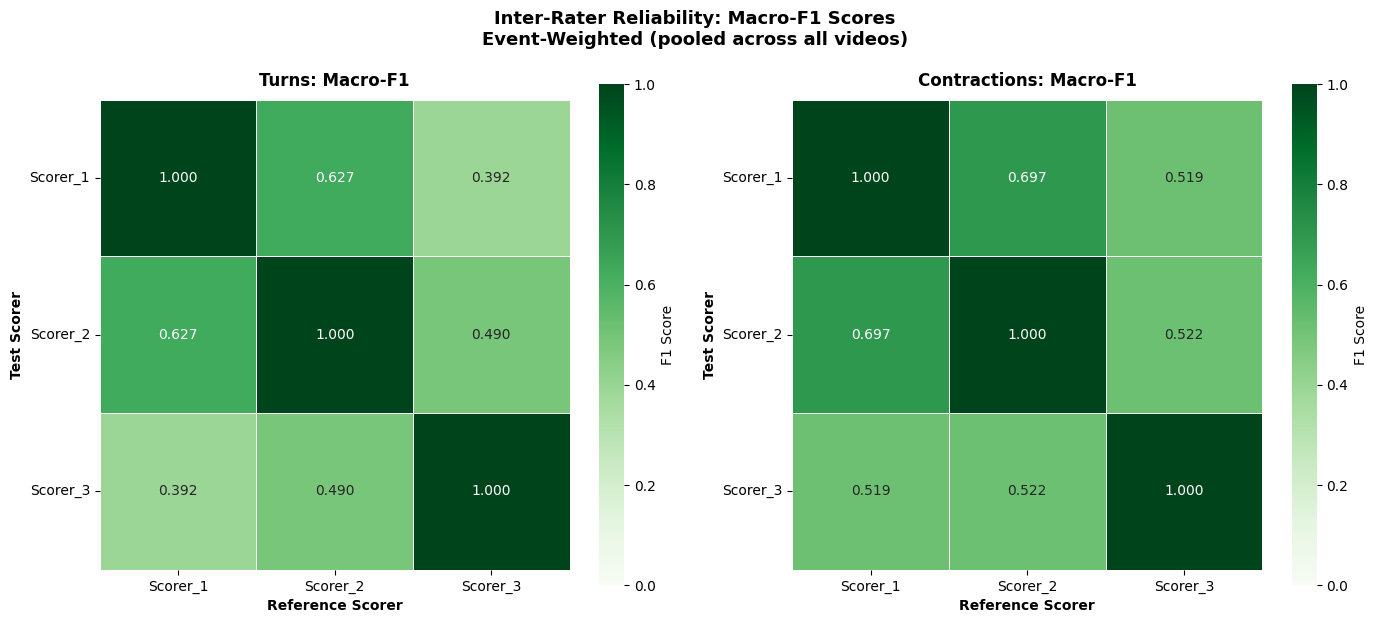

In [22]:
# ============================================================================
# F1 HEATMAP VISUALIZATION
# ============================================================================
# Purpose: Visualize pairwise F1 scores as heatmaps
# Input: f1_results DataFrame from previous cell
# Output: Heatmaps for Macro and Micro F1 scores
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def create_f1_heatmaps(f1_results, metric_type='Macro', cmap='Blues', figsize=(14, 6)):
    """
    Create side-by-side heatmaps for Turns and Contractions.
    
    Parameters:
    -----------
    f1_results : pandas DataFrame
        Output from calculate_all_f1_metrics()
        Columns: Type, Event, Reference, Test, Precision, Recall, F1
    
    metric_type : str
        'Macro' (event-weighted) or 'Micro' (video-weighted)
    
    cmap : str
        Matplotlib colormap (default 'Blues')
    
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes
    """
    
    # Filter for requested metric type
    df_filtered = f1_results[f1_results['Type'] == metric_type].copy()
    
    # Get unique scorers (sorted alphabetically)
    scorers = sorted(df_filtered['Reference'].unique())
    n_scorers = len(scorers)
    
    # Initialize matrices for both event types
    turn_matrix = np.zeros((n_scorers, n_scorers))
    contraction_matrix = np.zeros((n_scorers, n_scorers))
    
    # Fill Turn matrix
    # Matrix[i, j] = F1 when scorers[i] is reference, scorers[j] is test
    for i, ref in enumerate(scorers):
        for j, test in enumerate(scorers):
            if i == j:
                # Diagonal: perfect self-agreement
                turn_matrix[i, j] = 1.0
                contraction_matrix[i, j] = 1.0
            else:
                # Get F1 score for this pair
                turn_row = df_filtered[
                    (df_filtered['Event'] == 'Turns') &
                    (df_filtered['Reference'] == ref) &
                    (df_filtered['Test'] == test)
                ]
                
                contraction_row = df_filtered[
                    (df_filtered['Event'] == 'Contractions') &
                    (df_filtered['Reference'] == ref) &
                    (df_filtered['Test'] == test)
                ]
                
                turn_matrix[i, j] = turn_row['F1'].values[0] if len(turn_row) > 0 else np.nan
                contraction_matrix[i, j] = contraction_row['F1'].values[0] if len(contraction_row) > 0 else np.nan
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot TURNS heatmap
    # Note: We transpose so X-axis=Reference, Y-axis=Test (conventional layout)
    sns.heatmap(
        turn_matrix.T,
        annot=True,
        fmt='.3f',
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        square=True,
        cbar_kws={'label': 'F1 Score'},
        xticklabels=scorers,
        yticklabels=scorers,
        ax=axes[0],
        linewidths=0.5,
        linecolor='white'
    )
    
    axes[0].set_title(f'Turns: {metric_type}-F1', fontsize=12, fontweight='bold', pad=10)
    axes[0].set_xlabel('Reference Scorer', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('Test Scorer', fontsize=10, fontweight='bold')
    axes[0].set_xticklabels(scorers, rotation=0)
    axes[0].set_yticklabels(scorers, rotation=0)
    
    # Plot CONTRACTIONS heatmap
    sns.heatmap(
        contraction_matrix.T,
        annot=True,
        fmt='.3f',
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        square=True,
        cbar_kws={'label': 'F1 Score'},
        xticklabels=scorers,
        yticklabels=scorers,
        ax=axes[1],
        linewidths=0.5,
        linecolor='white'
    )
    
    axes[1].set_title(f'Contractions: {metric_type}-F1', fontsize=12, fontweight='bold', pad=10)
    axes[1].set_xlabel('Reference Scorer', fontsize=10, fontweight='bold')
    axes[1].set_ylabel('Test Scorer', fontsize=10, fontweight='bold')
    axes[1].set_xticklabels(scorers, rotation=0)
    axes[1].set_yticklabels(scorers, rotation=0)
    
    # Overall title
    if metric_type == 'Macro':
        subtitle = 'Event-Weighted (pooled across all videos)'
    else:
        subtitle = 'Video-Weighted (averaged per video)'
    
    fig.suptitle(f'Inter-Rater Reliability: {metric_type}-F1 Scores\n{subtitle}', 
                fontsize=13, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    
    # Print summary statistics
    print(f"\n{'='*70}")
    print(f"{metric_type.upper()}-F1 HEATMAP SUMMARY")
    print(f"{'='*70}")
    
    # Exclude diagonal (self-comparisons)
    turn_scores = turn_matrix[~np.eye(n_scorers, dtype=bool)]
    contr_scores = contraction_matrix[~np.eye(n_scorers, dtype=bool)]
    
    print(f"\nTURNS:")
    print(f"  Mean F1: {turn_scores.mean():.3f}")
    print(f"  Range: [{turn_scores.min():.3f}, {turn_scores.max():.3f}]")
    
    print(f"\nCONTRACTIONS:")
    print(f"  Mean F1: {contr_scores.mean():.3f}")
    print(f"  Range: [{contr_scores.min():.3f}, {contr_scores.max():.3f}]")
    
    print(f"\n{'='*70}\n")
    
    return fig, axes


# ============================================================================
# EXECUTE: Create heatmaps for both Macro and Micro
# ============================================================================

# Macro-F1 heatmaps (event-weighted)
# fig_macro, axes_macro = create_f1_heatmaps(f1_results_part3a, metric_type='Macro', cmap='Blues')
# plt.show()

# # Micro-F1 heatmaps (video-weighted)
# fig_micro, axes_micro = create_f1_heatmaps(f1_results, metric_type='Micro', cmap='Blues')
# plt.show()

# Macro-F1 heatmaps (event-weighted) - Part 3B method
fig_macro, axes_macro = create_f1_heatmaps(f1_results_part3b, metric_type='Macro', cmap='Greens')
# plt.show()

# # Micro-F1 heatmaps (video-weighted) - Part 3B method
# fig_micro, axes_micro = create_f1_heatmaps(f1_results, metric_type='Micro', cmap='Greens')
# plt.show()

## 6. - floating. Determine 3-way unaninmity. 

In [24]:
# ============================================================================
# VENN DIAGRAM ANALYSIS: Count Unique Events with Greedy Assignment
# ============================================================================

def assign_events_greedy(timestamp_combinations_df):
    """
    Use greedy assignment to count Venn diagram regions.
    
    Parameters:
    -----------
    timestamp_combinations_df : DataFrame
        Sorted triplets+pairs dataframe from analyze_video_timestamps
        (already sorted by diff_range, total_diff, triplets first)
    
    Returns:
    --------
    dict with counts:
        - 'S1S2S3': 3-way agreement count
        - 'S1S2': S1-S2 agreement (not S3)
        - 'S1S3': S1-S3 agreement (not S2)
        - 'S2S3': S2-S3 agreement (not S1)
        - 'S1_only': S1 orphans
        - 'S2_only': S2 orphans
        - 'S3_only': S3 orphans
        - 'S1_raw': total S1 timestamps
        - 'S2_raw': total S2 timestamps
        - 'S3_raw': total S3 timestamps
    """
    
    if len(timestamp_combinations_df) == 0:
        return {
            'S1S2S3': 0, 'S1S2': 0, 'S1S3': 0, 'S2S3': 0,
            'S1_only': 0, 'S2_only': 0, 'S3_only': 0,
            'S1_raw': 0, 'S2_raw': 0, 'S3_raw': 0
        }
    
    # Get raw counts (total timestamps per scorer)
    all_s1_indices = set()
    all_s2_indices = set()
    all_s3_indices = set()
    
    for _, row in timestamp_combinations_df.iterrows():
        if pd.notna(row['S1_index']):
            all_s1_indices.add(int(row['S1_index']))
        if pd.notna(row['S2_index']):
            all_s2_indices.add(int(row['S2_index']))
        if pd.notna(row['S3_index']):
            all_s3_indices.add(int(row['S3_index']))
    
    S1_raw = len(all_s1_indices)
    S2_raw = len(all_s2_indices)
    S3_raw = len(all_s3_indices)
    
    # Track which indices have been assigned
    matched_S1 = set()
    matched_S2 = set()
    matched_S3 = set()
    
    # Count Venn regions
    S1S2S3_count = 0
    S1S2_count   = 0
    S1S3_count   = 0
    S2S3_count   = 0
    
    # Process each combination in order (greedy assignment)
    for _, row in timestamp_combinations_df.iterrows():
        
        s1_idx = row['S1_index']
        s2_idx = row['S2_index']
        s3_idx = row['S3_index']
        
        # Check which indices are available (not yet matched)
        s1_available = pd.isna(s1_idx) or (int(s1_idx) not in matched_S1)
        s2_available = pd.isna(s2_idx) or (int(s2_idx) not in matched_S2)
        s3_available = pd.isna(s3_idx) or (int(s3_idx) not in matched_S3)
        
        # Determine which indices are present (not NaN)
        s1_present = pd.notna(s1_idx)
        s2_present = pd.notna(s2_idx)
        s3_present = pd.notna(s3_idx)
        
        # Only assign if ALL present indices are available
        all_available = True
        if s1_present and not s1_available:
            all_available = False
        if s2_present and not s2_available:
            all_available = False
        if s3_present and not s3_available:
            all_available = False
        
        if not all_available:
            continue
        
        combination_type = row['combination_type']
        
        if combination_type == 'triplet':
            s1s2_pass = row['S1S2_pass']
            s1s3_pass = row['S1S3_pass']
            s2s3_pass = row['S2S3_pass']
            
            if s1s2_pass and s1s3_pass and s2s3_pass:
                # 3-way agreement
                S1S2S3_count += 1
                matched_S1.add(int(s1_idx))
                matched_S2.add(int(s2_idx))
                matched_S3.add(int(s3_idx))
            
            elif s1s2_pass and s1s3_pass:
                # S1 agrees with both S2 and S3, but S2-S3 don't agree
                pass
            
            elif s1s2_pass and s2s3_pass:
                # S2 agrees with both, but S1-S3 don't agree
                pass
            
            elif s1s3_pass and s2s3_pass:
                # S3 agrees with both, but S1-S2 don't agree
                pass
            
            elif s1s2_pass:
                # Only S1-S2 agree (not S3)
                S1S2_count += 1
                matched_S1.add(int(s1_idx))
                matched_S2.add(int(s2_idx))
                matched_S3.add(int(s3_idx))  # S3 doesn't agree but is consumed
            
            elif s1s3_pass:
                # Only S1-S3 agree (not S2)
                S1S3_count += 1
                matched_S1.add(int(s1_idx))
                matched_S2.add(int(s2_idx))  # S2 doesn't agree but is consumed
                matched_S3.add(int(s3_idx))
            
            elif s2s3_pass:
                # Only S2-S3 agree (not S1)
                S2S3_count += 1
                matched_S1.add(int(s1_idx))  # S1 doesn't agree but is consumed
                matched_S2.add(int(s2_idx))
                matched_S3.add(int(s3_idx))
            
            # If agreement_count == 0, skip (too far apart)
        
        elif combination_type == 'pair':
            agreement_count = row['agreement_count']
            
            if agreement_count == 1:
                if s1_present and s2_present:
                    S1S2_count += 1
                    matched_S1.add(int(s1_idx))
                    matched_S2.add(int(s2_idx))
                
                elif s1_present and s3_present:
                    S1S3_count += 1
                    matched_S1.add(int(s1_idx))
                    matched_S3.add(int(s3_idx))
                
                elif s2_present and s3_present:
                    S2S3_count += 1
                    matched_S2.add(int(s2_idx))
                    matched_S3.add(int(s3_idx))
    
    # Count orphans (unmatched timestamps)
    S1_only = S1_raw - len(matched_S1)
    S2_only = S2_raw - len(matched_S2)
    S3_only = S3_raw - len(matched_S3)
    
    return {
        'S1S2S3': S1S2S3_count,
        'S1S2':   S1S2_count,
        'S1S3':   S1S3_count,
        'S2S3':   S2S3_count,
        'S1_only': S1_only,
        'S2_only': S2_only,
        'S3_only': S3_only,
        'S1_raw':  S1_raw,
        'S2_raw':  S2_raw,
        'S3_raw':  S3_raw
    }


def calculate_venn_statistics(venn_counts):
    """
    Apply inclusion-exclusion principle and calculate unanimity rate.
    
    Parameters:
    -----------
    venn_counts : dict
        Output from assign_events_greedy
    
    Returns:
    --------
    dict with:
        - 'total_unique_events': Total unique events (inclusion-exclusion)
        - 'unanimity_rate': S1S2S3 / Total
        - 'raw_counts': The input venn_counts for reference
    """
    
    S1 = venn_counts['S1_raw']
    S2 = venn_counts['S2_raw']
    S3 = venn_counts['S3_raw']
    
    S1S2 = venn_counts['S1S2'] + venn_counts['S1S2S3']
    S1S3 = venn_counts['S1S3'] + venn_counts['S1S2S3']
    S2S3 = venn_counts['S2S3'] + venn_counts['S1S2S3']
    
    S1S2S3 = venn_counts['S1S2S3']
    
    # Inclusion-exclusion formula
    total_unique_events = S1 + S2 + S3 - S1S2 - S1S3 - S2S3 + S1S2S3
    
    # Unanimity rate
    unanimity_rate = S1S2S3 / total_unique_events if total_unique_events > 0 else 0.0
    
    return {
        'total_unique_events': total_unique_events,
        'unanimity_rate':      unanimity_rate,
        'S1S2S3':              S1S2S3,
        'S1S2_total':          S1S2,
        'S1S3_total':          S1S3,
        'S2S3_total':          S2S3,
        'raw_counts':          venn_counts
    }


def analyze_video_unanimity(df, video_name, turn_threshold=15, contraction_threshold=15):
    """
    Calculate unanimity statistics for a single video.
    
    Parameters:
    -----------
    df : DataFrame
        Compiled scorer dataframe
    video_name : str
        Video identifier
    turn_threshold : int
        Frame threshold for turn matching
    contraction_threshold : int
        Frame threshold for contraction matching
    
    Returns:
    --------
    dict with keys 'turns' and 'contractions', each containing statistics
    """
    
    print(f"ANALYZING UNANIMITY FOR VIDEO: {video_name}")
    print("=" * 60)
    
    # Get the triplets+pairs dataframes
    results = analyze_video_timestamps(df, video_name, turn_threshold, contraction_threshold)
    
    # Analyze turns
    print("\n--- TURNS ---")
    if len(results['turns']) > 0:
        venn_counts_turns = assign_events_greedy(results['turns'])
        stats_turns = calculate_venn_statistics(venn_counts_turns)
        
        print(f"  3-way agreement (S1S2S3): {venn_counts_turns['S1S2S3']}")
        print(f"  2-way agreements:")
        print(f"    S1S2 only: {venn_counts_turns['S1S2']}")
        print(f"    S1S3 only: {venn_counts_turns['S1S3']}")
        print(f"    S2S3 only: {venn_counts_turns['S2S3']}")
        print(f"  Orphans:")
        print(f"    S1 only: {venn_counts_turns['S1_only']}")
        print(f"    S2 only: {venn_counts_turns['S2_only']}")
        print(f"    S3 only: {venn_counts_turns['S3_only']}")
        print(f"  Total unique events: {stats_turns['total_unique_events']}")
        print(f"  Unanimity rate: {stats_turns['unanimity_rate']:.2%}")
    else:
        stats_turns = None
        print("  No turn data")
    
    # Analyze contractions
    print("\n--- CONTRACTIONS ---")
    if len(results['contractions']) > 0:
        venn_counts_contractions = assign_events_greedy(results['contractions'])
        stats_contractions = calculate_venn_statistics(venn_counts_contractions)
        
        print(f"  3-way agreement (S1S2S3): {venn_counts_contractions['S1S2S3']}")
        print(f"  2-way agreements:")
        print(f"    S1S2 only: {venn_counts_contractions['S1S2']}")
        print(f"    S1S3 only: {venn_counts_contractions['S1S3']}")
        print(f"    S2S3 only: {venn_counts_contractions['S2S3']}")
        print(f"  Orphans:")
        print(f"    S1 only: {venn_counts_contractions['S1_only']}")
        print(f"    S2 only: {venn_counts_contractions['S2_only']}")
        print(f"    S3 only: {venn_counts_contractions['S3_only']}")
        print(f"  Total unique events: {stats_contractions['total_unique_events']}")
        print(f"  Unanimity rate: {stats_contractions['unanimity_rate']:.2%}")
    else:
        stats_contractions = None
        print("  No contraction data")
    
    return {
        'turns': stats_turns,
        'contractions': stats_contractions
    }


def analyze_all_videos_unanimity(df, turn_threshold=15, contraction_threshold=15):
    """
    Calculate unanimity statistics across all videos in the dataset.
    
    Returns:
    --------
    DataFrame with one row per video showing unanimity metrics
    """
    
    results_list = []
    
    for video_name in df['Video']:
        print(f"\n{'='*80}")
        video_stats = analyze_video_unanimity(df, video_name, turn_threshold, contraction_threshold)
        
        if video_stats['turns'] is not None:
            results_list.append({
                'Video':               video_name,
                'Event_Type':          'Turns',
                'Total_Unique_Events': video_stats['turns']['total_unique_events'],
                'S1S2S3':              video_stats['turns']['S1S2S3'],
                'Unanimity_Rate':      video_stats['turns']['unanimity_rate'],
                'S1_Raw':              video_stats['turns']['raw_counts']['S1_raw'],
                'S2_Raw':              video_stats['turns']['raw_counts']['S2_raw'],
                'S3_Raw':              video_stats['turns']['raw_counts']['S3_raw']
            })
        
        if video_stats['contractions'] is not None:
            results_list.append({
                'Video':               video_name,
                'Event_Type':          'Contractions',
                'Total_Unique_Events': video_stats['contractions']['total_unique_events'],
                'S1S2S3':              video_stats['contractions']['S1S2S3'],
                'Unanimity_Rate':      video_stats['contractions']['unanimity_rate'],
                'S1_Raw':              video_stats['contractions']['raw_counts']['S1_raw'],
                'S2_Raw':              video_stats['contractions']['raw_counts']['S2_raw'],
                'S3_Raw':              video_stats['contractions']['raw_counts']['S3_raw']
            })
    
    results_df = pd.DataFrame(results_list)
    
    # Print aggregate statistics
    print("\n" + "="*80)
    print("AGGREGATE STATISTICS ACROSS ALL VIDEOS")
    print("="*80)
    
    for event_type in ['Turns', 'Contractions']:
        subset = results_df[results_df['Event_Type'] == event_type]
        
        if len(subset) > 0:
            print(f"\n{event_type}:")
            print(f"  Total unique events (sum): {subset['Total_Unique_Events'].sum()}")
            print(f"  Total unanimous events (sum): {subset['S1S2S3'].sum()}")
            print(f"  Overall unanimity rate: {subset['S1S2S3'].sum() / subset['Total_Unique_Events'].sum():.2%}")
            print(f"  Mean unanimity per video: {subset['Unanimity_Rate'].mean():.2%} (±{subset['Unanimity_Rate'].std():.2%})")
    
    return results_df


# ============================================================================
# RUN ANALYSIS
# ============================================================================

unanimity_results = analyze_all_videos_unanimity(df, 
                                                  turn_threshold=10, 
                                                  contraction_threshold=15)

display(unanimity_results)

unanimity_results.to_csv('unanimity_results.csv', index=False)


ANALYZING UNANIMITY FOR VIDEO: Ahead_Tasty_Chicory
ANALYZING VIDEO: Ahead_Tasty_Chicory

Timestamp counts:
  Turns:
    Scorer_1: 2
    Scorer_2: 1
    Scorer_3: 0
  Contractions:
    Scorer_1: 1
    Scorer_2: 0
    Scorer_3: 0

Creating permutations (triplets + pairs)...
  Turns: 2 total combinations (0 triplets, 2 pairs)
  Contractions: 0 combinations

  Turn PAIR agreement distribution:
    Agreement: 0
    No agreement: 2

--- TURNS ---
  3-way agreement (S1S2S3): 0
  2-way agreements:
    S1S2 only: 0
    S1S3 only: 0
    S2S3 only: 0
  Orphans:
    S1 only: 2
    S2 only: 1
    S3 only: 0
  Total unique events: 3
  Unanimity rate: 0.00%

--- CONTRACTIONS ---
  No contraction data

ANALYZING UNANIMITY FOR VIDEO: Abhorrent_Jittery_Trap
ANALYZING VIDEO: Abhorrent_Jittery_Trap

Timestamp counts:
  Turns:
    Scorer_1: 5
    Scorer_2: 5
    Scorer_3: 2
  Contractions:
    Scorer_1: 0
    Scorer_2: 0
    Scorer_3: 0

Creating permutations (triplets + pairs)...
  Turns: 95 total combin

,Video,Event_Type,Total_Unique_Events,S1S2S3,Unanimity_Rate,S1_Raw,S2_Raw,S3_Raw
0,Ahead_Tasty_Chicory,Turns,3,0,0.000000,2,1,0
1,Abhorrent_Jittery_Trap,Turns,6,2,0.333333,5,5,2
2,Aback_Gentle_Deduce,Turns,3,0,0.000000,2,1,1
3,Aback_Gentle_Deduce,Contractions,2,1,0.500000,2,1,1
4,Abounding_Wholesale_Van,Turns,4,2,0.500000,4,4,2
...,...,...,...,...,...,...,...,...
238,Whispering_Hurried_Solution,Turns,3,0,0.000000,2,1,1
239,Whispering_Hurried_Solution,Contractions,2,0,0.000000,1,1,1
240,Wiry_Synonymous_Intensity,Turns,4,0,0.000000,3,2,1
241,Wiry_Synonymous_Intensity,Contractions,1,0,0.000000,1,1,0
